Make a plot of planetary radius as a function of equilibrium temperature and investigate whether there is a clear transition where inflation becomes significant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import csv

In [139]:
temps = []
radii = []
sm_as = []
names = []
st_lums = []
st_masss = []
st_mets = []
st_rads = []

fluxes = []
distances = []
increase_percent = []


# temp_uncs = {
#     "plus" : plus,

# }

with open("PSCompPars_2026(1485).csv", newline='') as file:
    for line in file:
        if not line.startswith("#"):  # first non-metadata line
            header_line = line
            break

    reader = csv.DictReader(file, fieldnames=header_line.strip().split(","))
    # print(reader.fieldnames)

    for row in reader:
        if row["pl_eqt"] and row["pl_radj"] and row["st_lum"] and row["st_mass"] and row["st_met"] and row["pl_orbsmax"] and row["pl_name"] and row["st_rad"]:
            temps.append(float(row["pl_eqt"]))
            radii.append(float(row["pl_radj"]))
            sm_as.append(float(row["pl_orbsmax"]))
            st_lums.append(float(row["st_lum"]))
            st_masss.append(float(row["st_mass"]))
            st_mets.append(float(row["st_met"]))
            st_rads.append(float(row["st_rad"]))
            names.append(row["pl_name"])


for pl_rad, st_rad, sm_a in zip(radii, st_rads, sm_as):
    dist = sm_a - (st_rad + pl_rad)
    distances.append(dist)

for temp, pl_rad, sm_a, name, st_lum, st_mass, st_met, st_rad, dist in zip(temps, radii, sm_as, names, st_lums, st_masss, st_mets, st_rads, distances):
    if st_lum / (4 * np.pi * dist ** 2) > 1:
        temps.remove(temp)
        radii.remove(pl_rad)
        sm_as.remove(sm_a)
        names.remove(name)
        st_lums.remove(st_lum)
        st_masss.remove(st_mass)
        st_mets.remove(st_met)
        st_rads.remove(st_rad)
        distances.remove(dist)

    elif st_lum / (4 * np.pi * dist ** 2) < -0.8:
        temps.remove(temp)
        radii.remove(pl_rad)
        sm_as.remove(sm_a)
        names.remove(name)
        st_lums.remove(st_lum)
        st_masss.remove(st_mass)
        st_mets.remove(st_met)
        st_rads.remove(st_rad)
        distances.remove(dist)

for lum, dist in zip(st_lums, distances):
    flux = lum / (4 * np.pi * (dist ** 2))
    fluxes.append(flux)

for temp, rad in zip(temps, radii):
    exp_rad = (1.1 * temp ** 0.35) / 11 # /11 to convert to Jupiter Radius
    increase = ((rad / exp_rad) - 1) * 100 # *100 to get a percentage
    increase_percent.append(increase)


In [3]:
J_temp = 122
J_rad = 1

In [129]:
def plot1(temp, rad):
    plt.figure(figsize=(12,8))
    plt.scatter(temp, rad, s=10, label="Hot Jupiter")

    plt.scatter(J_temp, J_rad, color="red", s=10, label="Jupiter")

    x = np.linspace(min(temp), max(temp), 200)
    y = (1.1 * x ** 0.35) / 11
    plt.plot(x, y, linestyle="-", color="black", label="Edmonson Et al.")

    plt.xlabel("Equilibrium Temperature (°K)")
    plt.ylabel("Planetary Radius ($J_{rad}$)")
    plt.title("Figure 1")

    plt.legend()
    plt.show()


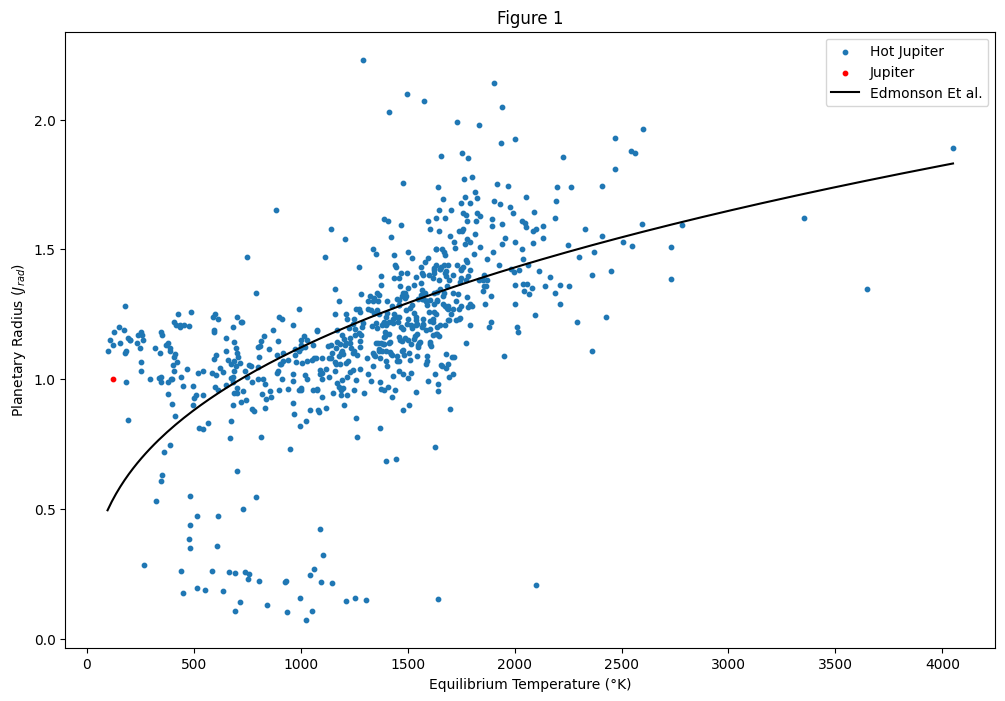

In [130]:
plot1(temps, radii)

How does the degree of inflation depend on incident flux?

In [140]:

print(f"{len(temps)=}")
print(f"{len(radii)=}")
print(f"{len(sm_as)=}")
print(f"{len(names)=}")
print(f"{len(st_lums)=}")
print(f"{len(st_masss)=}")
print(f"{len(st_mets)=}")
print(f"{len(st_rads)=}")

print()

print(f"{len(distances)=}")
print(f"{len(fluxes)=}")
print(f"{len(increase_percent)=}")


len(temps)=718
len(radii)=718
len(sm_as)=718
len(names)=718
len(st_lums)=718
len(st_masss)=718
len(st_mets)=718
len(st_rads)=718

len(distances)=718
len(fluxes)=718
len(increase_percent)=718


In [123]:
def plot2(flux, percent, xaxis, yaxis, a):
    plt.figure(figsize=(12,8))
    plt.scatter(flux, percent, s=10)

    plt.xlabel(xaxis)
    plt.ylabel(yaxis)
    plt.title(f"Figure {a}")

    plt.show()


<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\macau\AppData\Local\Temp\ipykernel_47680\234231256.py:1: SyntaxWarning: invalid escape sequence '\c'
  plot2(fluxes, increase_percent, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)", 2)


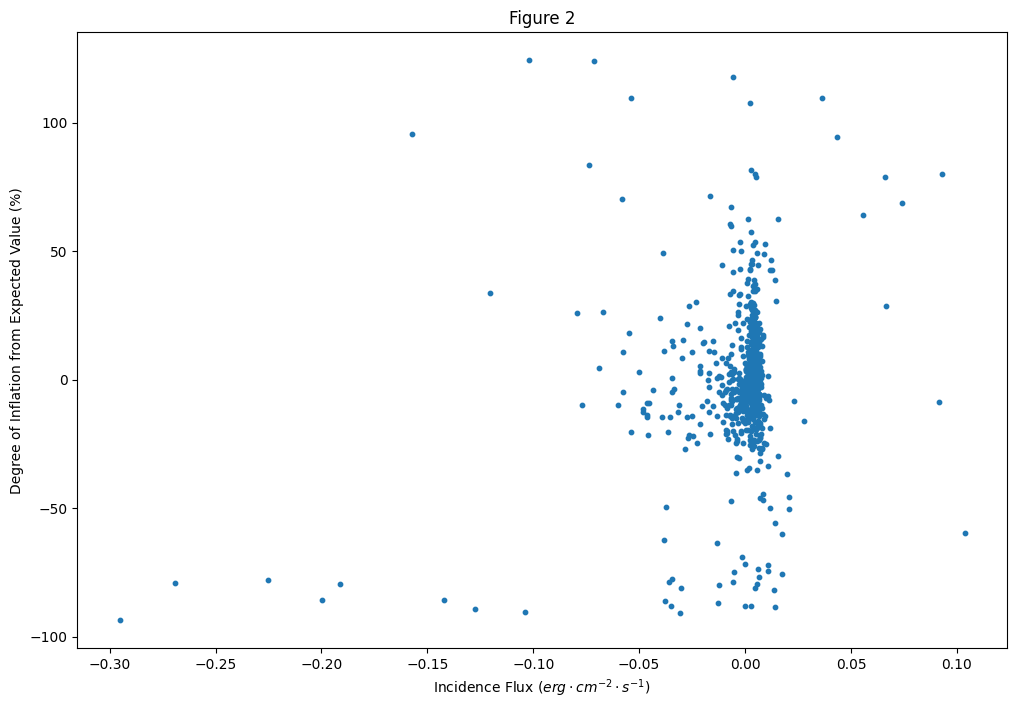

In [141]:
plot2(fluxes, increase_percent, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)", 2)

Are there correlations with host star properties such as mass or metallicity?

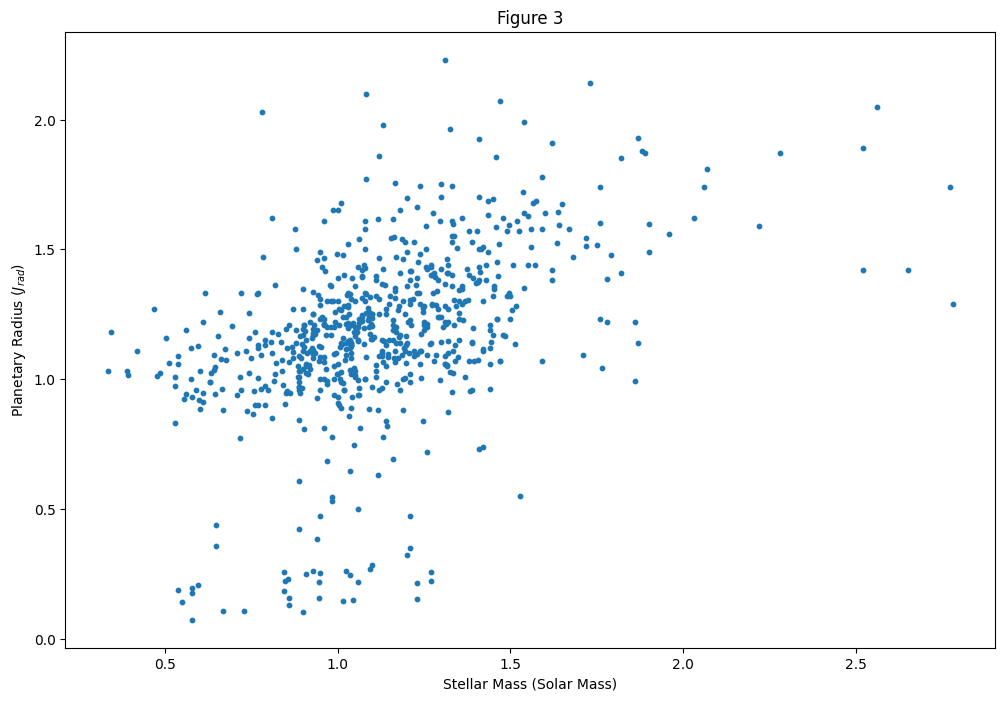

In [127]:
plot2(st_masss, radii, "Stellar Mass (Solar Mass)", "Planetary Radius ($J_{rad}$)", 3)

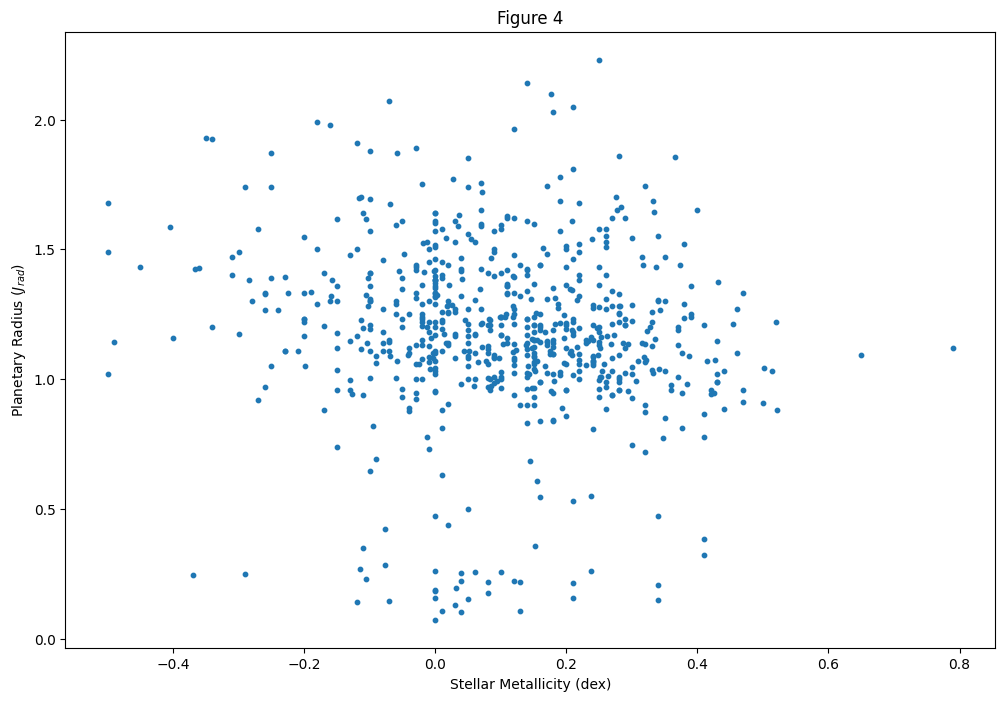

In [128]:
plot2(st_mets, radii, "Stellar Metallicity (dex)", "Planetary Radius ($J_{rad}$)", 4)

How large are the observational uncertainties, and how do they affect your conclusions?